[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Folders Created Successfully
                                                text
0         machine learning is transforming the world
1  natural language processing improves communica...
2               autocomplete helps users type faster
3             autocorrect improves spelling accuracy
4            data analytics provides useful insights
                                                text  \
0         machine learning is transforming the world   
1  natural language processing improves communica...   
2               autocomplete helps users type faster   
3             autocorrect improves spelling accuracy   
4            data analytics provides useful insights   

                                          clean_text  
0         machine learning is transforming the world  
1  natural language processing improves communica...  
2               autocomplete helps users type faster  
3             autocorrect improves spelling accuracy  
4            data analytics provides usef

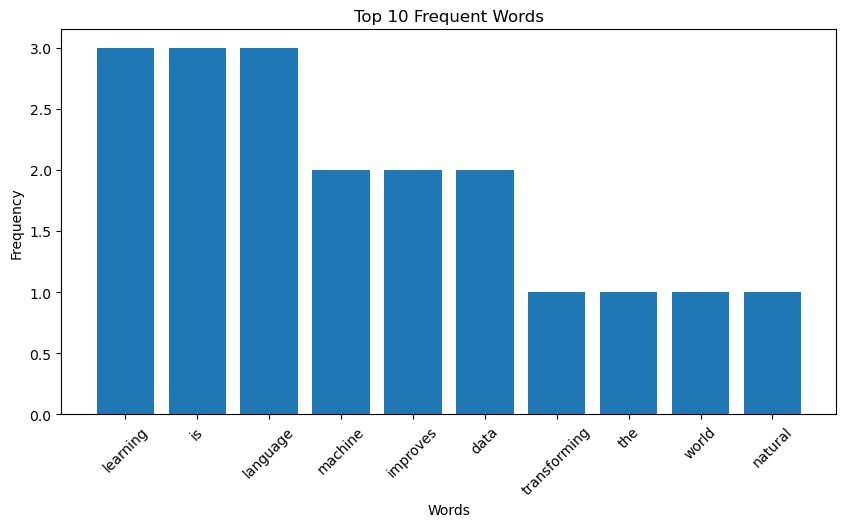


Results Saved Successfully
  Input Word                                Predictions
0    machine                            [(learning, 2)]
1       data             [(analytics, 1), (science, 1)]
2   language  [(processing, 1), (models, 1), (data, 1)]


Project Folder Structure:

Project Folder/
│
├── project.py
│
├── outputs/
│   ├── graphs/
│   │   └── top_words.png
│   │
│   └── results/
│       └── autocomplete_results.csv




In [4]:
# =========================================================
# AUTOCOMPLETE AND AUTOCORRECT DATA ANALYTICS PROJECT
# =========================================================

# -----------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------

import os
import re
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from textblob import TextBlob
from sklearn.metrics import accuracy_score

# Download tokenizer
nltk.download('punkt')

# -----------------------------
# STEP 2: CREATE PROJECT FOLDERS
# -----------------------------

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/graphs", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

print("Folders Created Successfully")

# -----------------------------
# STEP 3: CREATE SAMPLE TEXT DATASET
# -----------------------------

text_data = [
    "machine learning is transforming the world",
    "natural language processing improves communication",
    "autocomplete helps users type faster",
    "autocorrect improves spelling accuracy",
    "data analytics provides useful insights",
    "python is widely used in artificial intelligence",
    "deep learning is a branch of machine learning",
    "text prediction enhances user experience",
    "language models understand human language",
    "data science combines statistics and programming"
]

df = pd.DataFrame(text_data, columns=["text"])

print(df.head())

# -----------------------------
# STEP 4: NLP PREPROCESSING
# -----------------------------

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

print(df.head())

# -----------------------------
# STEP 5: TOKENIZATION
# -----------------------------

tokens = []

for sentence in df['clean_text']:
    tokens.extend(word_tokenize(sentence))

print("\nTotal Tokens:", len(tokens))
print(tokens[:20])

# -----------------------------
# STEP 6: BUILD AUTOCOMPLETE SYSTEM
# USING BIGRAMS
# -----------------------------

bigrams = list(ngrams(tokens, 2))

bigram_freq = Counter(bigrams)

print("\nTop 10 Bigrams:")
print(bigram_freq.most_common(10))

# -----------------------------
# AUTOCOMPLETE FUNCTION
# -----------------------------

def autocomplete(word, top_n=5):

    predictions = {}

    for (w1, w2), freq in bigram_freq.items():

        if w1 == word:
            predictions[w2] = freq

    sorted_predictions = sorted(
        predictions.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return sorted_predictions[:top_n]

# Example
print("\nAutocomplete Example:")
print(autocomplete("machine"))

# -----------------------------
# STEP 7: BUILD AUTOCORRECT SYSTEM
# -----------------------------

def autocorrect(word):

    corrected = str(TextBlob(word).correct())

    return corrected

# Example wrong words
wrong_words = ["machne", "lernning", "langauge", "pythn"]

print("\nAutocorrect Results:")

for word in wrong_words:

    print(f"{word} --> {autocorrect(word)}")

# -----------------------------
# STEP 8: PERFORMANCE METRICS
# -----------------------------

actual_words = ["machine", "learning", "language", "python"]

incorrect_words = ["machne", "lernning", "langauge", "pythn"]

predicted_words = [autocorrect(word) for word in incorrect_words]

accuracy = accuracy_score(actual_words, predicted_words)

print("\nAutocorrect Accuracy:", accuracy)

# -----------------------------
# STEP 9: VISUALIZATION
# -----------------------------

word_freq = Counter(tokens)

common_words = word_freq.most_common(10)

words = [i[0] for i in common_words]
counts = [i[1] for i in common_words]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 10 Frequent Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

# Save graph
plt.savefig("outputs/graphs/top_words.png")

plt.show()

# -----------------------------
# STEP 10: SAVE RESULTS
# -----------------------------

results = []

test_words = ["machine", "data", "language"]

for word in test_words:

    preds = autocomplete(word)

    results.append({
        "Input Word": word,
        "Predictions": preds
    })

results_df = pd.DataFrame(results)

# Save CSV
results_df.to_csv(
    "outputs/results/autocomplete_results.csv",
    index=False
)

print("\nResults Saved Successfully")

print(results_df)

# -----------------------------
# FINAL PROJECT OUTPUT
# -----------------------------

print("""

Project Folder Structure:

Project Folder/
│
├── project.py
│
├── outputs/
│   ├── graphs/
│   │   └── top_words.png
│   │
│   └── results/
│       └── autocomplete_results.csv

""")